In [12]:
import tempfile
from datetime import datetime
from multiprocessing import cpu_count
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from numba import njit
from hftbacktest import (
    BUY,
    SELL,
    GTC,
    LIMIT,
    BacktestAssetPoly,
    ROIVectorMarketDepthBacktest,
    Recorder,
    init_orderbook,
    polymarket_to_hbt,
)
from hftbacktest.stats import PolyAssetRecord

%matplotlib inline

In [13]:
coin = "xrp"
start = datetime.fromisoformat("2026-03-12T08:15:00+00:00")
end = datetime.fromisoformat("2026-03-20T08:15:00+00:00")

market_times = pd.date_range(start=start, end=end, freq="5min", inclusive="left")
market_times[:5]

DatetimeIndex(['2026-03-12 08:15:00+00:00', '2026-03-12 08:20:00+00:00',
               '2026-03-12 08:25:00+00:00', '2026-03-12 08:30:00+00:00',
               '2026-03-12 08:35:00+00:00'],
              dtype='datetime64[us, UTC]', freq='5min')

In [14]:
DATA_CACHE_DIR = Path(tempfile.gettempdir()) / "pm_hbt_example_cache"
L2_CACHE_DIR = DATA_CACHE_DIR / "poly_l2"
HBT_CACHE_DIR = DATA_CACHE_DIR / "poly_hbt"
L2_CACHE_DIR.mkdir(parents=True, exist_ok=True)
HBT_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_5m_slug(asset_prefix: str, ts) -> str:
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    start_s = int(ts.timestamp()) // 300 * 300
    return f"{asset_prefix}-updown-5m-{start_s}"


def get_hbt_data(slug: str):
    hbt_path = HBT_CACHE_DIR / f"{slug}.npz"
    if hbt_path.exists():
        return np.load(hbt_path)["data"]

    parquet_path = L2_CACHE_DIR / f"{slug}.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
    else:
        df = pd.read_parquet(
            f"https://s.wangshuox.com/poly_l2/{slug}.parquet",
            storage_options={"User-Agent": "Mozilla/5.0"},
        )
        if "condition_id" in df.columns:
            df = df.drop(columns=["condition_id"])
        df.to_parquet(parquet_path)

    data = polymarket_to_hbt(df)
    np.savez_compressed(hbt_path, data=data)
    return data


slugs = [build_5m_slug(coin, ts) for ts in market_times]
slugs[:5]

['xrp-updown-5m-1773303300',
 'xrp-updown-5m-1773303600',
 'xrp-updown-5m-1773303900',
 'xrp-updown-5m-1773304200',
 'xrp-updown-5m-1773304500']

In [ ]:
def _warm_up_one(slug: str) -> str | None:
    try:
        get_hbt_data(slug)
        return slug
    except Exception:
        return None


def warm_up_hbt_data(slugs: list[str], n_jobs: int | None = None) -> set[str]:
    rows = Parallel(n_jobs=n_jobs or cpu_count(), backend="loky")(
        delayed(_warm_up_one)(slug) for slug in slugs
    )
    return {slug for slug in rows if slug is not None}


warm_up_hbt_data(slugs)

In [16]:
_NS_PER_S = 1_000_000_000


@njit
def reverse_trading(
    hbt,
    recorder,
    entry_price: float,
    stop_earn: float,
    market_start_s: int,
    cancel_after_s: int,
):
    asset_no = 0
    if not init_orderbook(hbt, asset_no):
        return

    tick_size = 0.01
    qty = np.ceil(1 / entry_price)

    buy_price = entry_price
    sell_price = 1.0 - entry_price
    buy_order_id = int(round(buy_price / tick_size))
    sell_order_id = int(round(sell_price / tick_size))

    stop_buy_price = 1.0 - stop_earn
    stop_sell_price = stop_earn
    stop_buy_order_id = int(round(stop_buy_price / tick_size))
    stop_sell_order_id = int(round(stop_sell_price / tick_size))

    hbt.submit_buy_order(asset_no, buy_order_id, buy_price, qty, GTC, LIMIT, False)
    hbt.submit_sell_order(asset_no, sell_order_id, sell_price, qty, GTC, LIMIT, False)
    recorder.record(hbt)

    entry_closed = False
    stop_order_submitted = False
    stop_order_side = 0
    deadline_ns = market_start_s * _NS_PER_S + cancel_after_s * _NS_PER_S

    while hbt.elapse(100_000_000) == 0:
        hbt.clear_inactive_orders(asset_no)
        position = hbt.position(asset_no)

        if (not entry_closed) and hbt.current_timestamp >= deadline_ns:
            hbt.cancel(asset_no, buy_order_id, False)
            hbt.cancel(asset_no, sell_order_id, False)
            entry_closed = True

        if (not stop_order_submitted) and position > 0.0:
            hbt.cancel(asset_no, sell_order_id, False)
            hbt.submit_sell_order(
                asset_no,
                stop_sell_order_id,
                stop_sell_price,
                position,
                GTC,
                LIMIT,
                False,
            )
            entry_closed = True
            stop_order_submitted = True
            stop_order_side = SELL
        elif (not stop_order_submitted) and position < 0.0:
            hbt.cancel(asset_no, buy_order_id, False)
            hbt.submit_buy_order(
                asset_no,
                stop_buy_order_id,
                stop_buy_price,
                -position,
                GTC,
                LIMIT,
                False,
            )
            entry_closed = True
            stop_order_submitted = True
            stop_order_side = BUY

        if stop_order_submitted:
            if stop_order_side == SELL and position <= 0.0:
                stop_order_submitted = False
            elif stop_order_side == BUY and position >= 0.0:
                stop_order_submitted = False

        recorder.record(hbt)

In [17]:
BOOK_SIZE = 1000


def run_slug_backtest(
    slug: str,
    market_start_s: int,
    entry_price: float,
    stop_earn: float,
    cancel_after_s: int,
) -> float:
    data = get_hbt_data(slug)
    asset = BacktestAssetPoly().data(data)
    hbt = ROIVectorMarketDepthBacktest([asset])
    recorder = Recorder(hbt.num_assets, 5_000_000)

    reverse_trading(
        hbt,
        recorder.recorder,
        entry_price=entry_price,
        stop_earn=stop_earn,
        market_start_s=market_start_s,
        cancel_after_s=cancel_after_s,
    )
    _ = hbt.close()

    stats = PolyAssetRecord(recorder.get(0)).stats(book_size=BOOK_SIZE)
    return float(stats.earn)


def _run_one_market(ts, entry_price: float, stop_earn: float, cancel_after_s: int):
    slug = build_5m_slug(coin, ts)

    try:
        earn = run_slug_backtest(
            slug=slug,
            market_start_s=int(pd.Timestamp(ts).timestamp()),
            entry_price=entry_price,
            stop_earn=stop_earn,
            cancel_after_s=cancel_after_s,
        )
        return {"time": ts, "slug": slug, "earn": earn, "skipped": False}
    except Exception:
        return {"time": ts, "slug": slug, "earn": np.nan, "skipped": True}


def backtest_markets(
    market_times,
    entry_price: float,
    stop_earn: float,
    cancel_after_s: int,
    n_jobs: int | None = None,
) -> pd.DataFrame:
    rows = Parallel(n_jobs=n_jobs or cpu_count(), backend="loky")(
        delayed(_run_one_market)(ts, entry_price, stop_earn, cancel_after_s)
        for ts in market_times
    )
    return pd.DataFrame(rows).set_index("time")

In [ ]:
entry_price = 0.07
stop_earn = 0.9
cancel_after_s = 270

df_bt = backtest_markets(
    market_times,
    entry_price=entry_price,
    stop_earn=stop_earn,
    cancel_after_s=cancel_after_s,
)

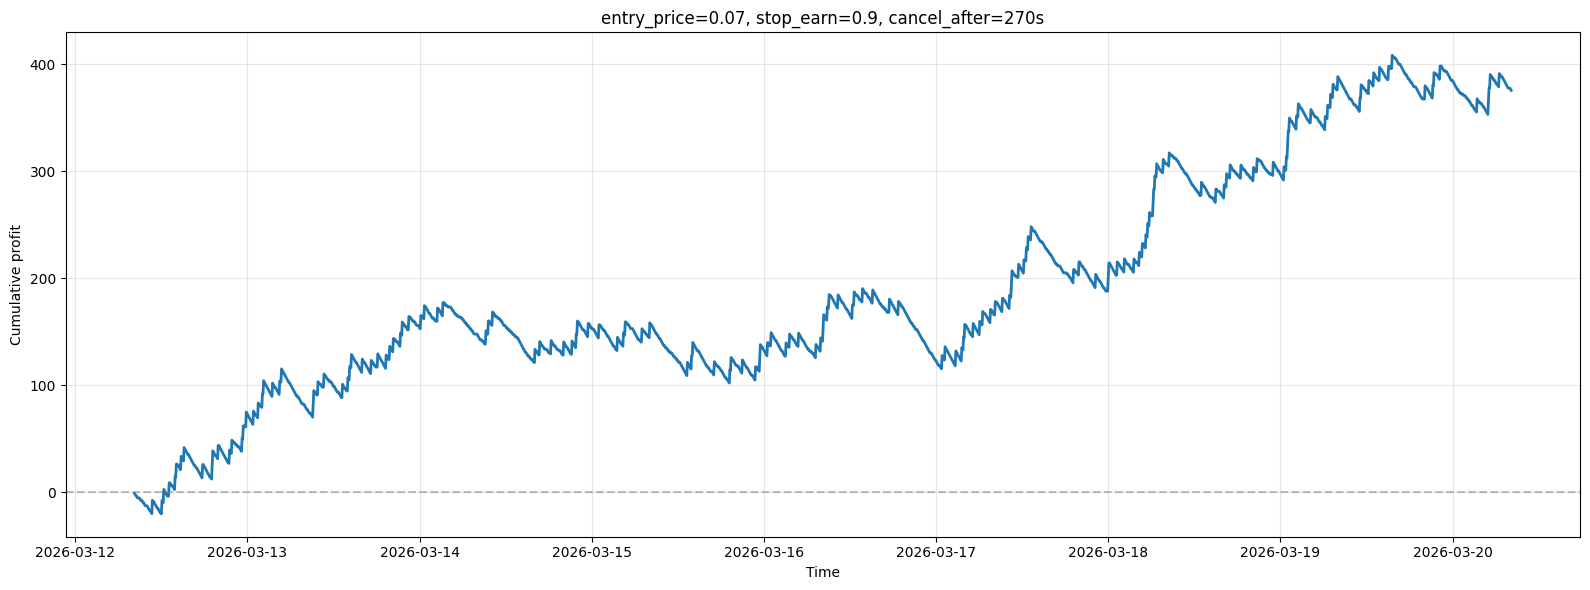

In [19]:
df_bt["cum_earn"] = df_bt["earn"].fillna(0).cumsum()
df_bt.head()
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_bt.index, df_bt["cum_earn"], linewidth=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Cumulative profit")
ax.set_xlabel("Time")
ax.set_title(
    f"entry_price={entry_price}, stop_earn={stop_earn}, cancel_after={cancel_after_s}s"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()